In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
# Load the dataset
data = pd.read_csv('Documents/MASTER 2024/Summer 2024/Practical Data Analytics/breast-cancer.csv')

# Separate features and target variable
X = data.drop(columns=['ID', 'Class'])  # Features
y = data['Class']  # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

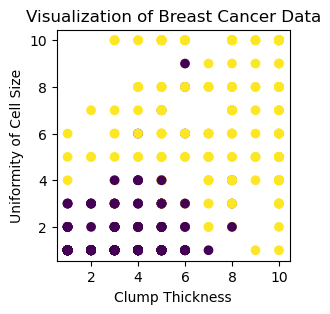

In [12]:
# Visualize the distribution of classes
plt.figure(figsize=(3,3))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y)
plt.xlabel('Clump Thickness')
plt.ylabel('Uniformity of Cell Size')
plt.title('Visualization of Breast Cancer Data')
plt.show()


In [23]:
# Define numerical features (all features are numerical)
numerical_features = X_train.columns.tolist()

# Define the preprocessing steps for numerical features
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Combine preprocessing steps into a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features)
    ])

# Define the SVC model pipeline
svc_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('svc', SVC())
])

In [20]:
# Define the parameter grid for GridSearchCV
param_grid = [
    {'svc__kernel': ['linear'], 'svc__C': [0.001, 0.1, 1, 10, 100]},
    {'svc__kernel': ['poly'], 'svc__C': [0.001, 0.1, 1, 10, 100], 'svc__degree': [2, 3, 4], 'svc__coef0': [0, 1, 10]},
    {'svc__kernel': ['rbf'], 'svc__C': [0.001, 0.01, 0.1, 1, 10, 100], 'svc__gamma': [0.001, 0.01, 0.1, 1, 10, 100]}
]

# Perform GridSearchCV
grid_search = GridSearchCV(svc_pipeline, param_grid, cv=5, scoring='accuracy', return_train_score=True)
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search.best_score_))


Best parameters found:  {'svc__C': 1, 'svc__coef0': 1, 'svc__degree': 2, 'svc__kernel': 'poly'}
Best cross-validation accuracy: 0.97


In [24]:
# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print("Test set accuracy of the best model: {:.2f}".format(test_accuracy))


Test set accuracy of the best model: 0.97


In [25]:
# Use only the first two features for visualization
X_train_2d = X_train.iloc[:, :2].values
X_test_2d = X_test.iloc[:, :2].values

# Fit models on the first two features
lsvc_2d = SVC(kernel='linear', C=1000).fit(X_train_2d, y_train)
svc_rbf_2d = SVC(kernel='rbf', gamma=1, C=2).fit(X_train_2d, y_train)
svc_poly_2d = SVC(kernel='poly', degree=3, coef0=2).fit(X_train_2d, y_train)

models_2d = [lsvc_2d, svc_rbf_2d, svc_poly_2d]
titles = ['Linear kernel', 'RBF kernel', 'Polynomial kernel']


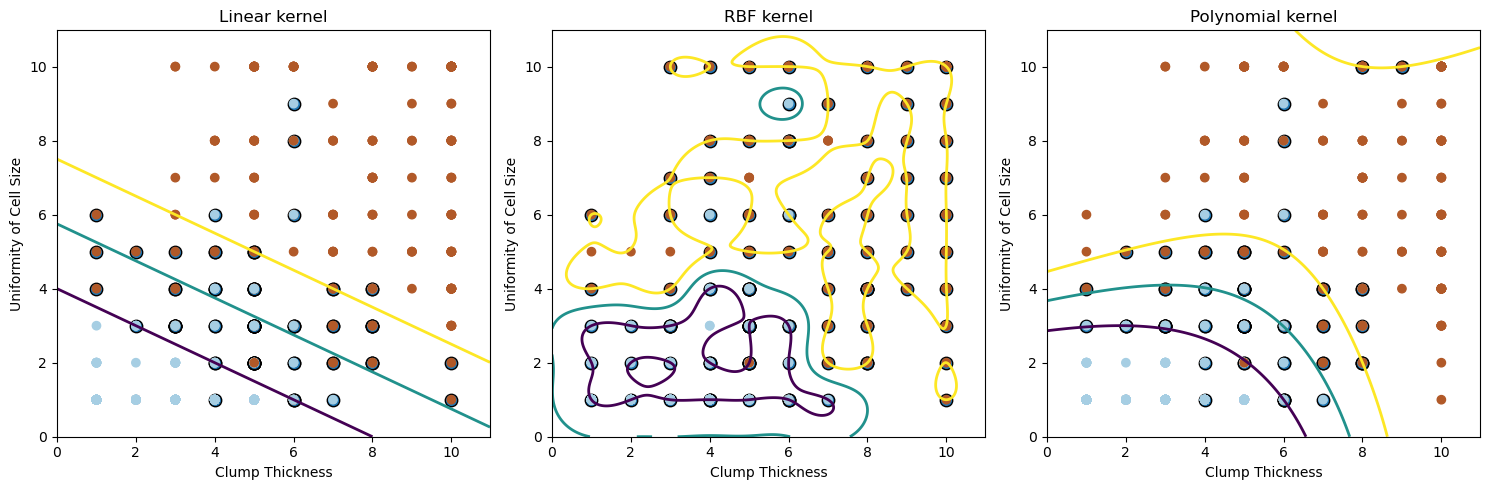

In [26]:
# Create meshgrid for plotting decision boundaries
h = 0.02
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Plot decision boundaries for each model
plt.figure(figsize=(15, 5))
for i, clf in enumerate(models_2d):
    plt.subplot(1, 3, i + 1)
    
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contour(xx, yy, Z, levels=[-1, 0, 1], linewidths=2)
    plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=80, edgecolors='k')
    plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap=plt.cm.Paired)
    plt.title(titles[i])
    plt.xlabel('Clump Thickness')
    plt.ylabel('Uniformity of Cell Size')

plt.tight_layout()
plt.show()
